In [ ]:
import numpy as np
import pandas as pd
import matplotlib as plt
import math

: 

In [ ]:
class Value:

    def __init__(self, data, child=(), op="", label=""):
        self.data = data
        self.grad = 0.0
        self.label = label
        self._child = set(child)
        self._op = op
        self._backward = lambda: None
    
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, child=(self, other), op="+")
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __radd__(self, other): # other + self
        return self + other

    def __sub__(self, other):
        return self + (-other)

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, child=(self, other), op="*")
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        out = Value(self.data ** other, (self, ), "**{other}")
        def _backward():
            self.grad += other * self.data ** (other - 1) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, (self, ), "tanh")

        def _backward():
            self.grad += (1 - t ** 2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), "exp")

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
    
    def get_topo(self) -> list["Value"]:
        topo = []
        visited = set()
        def build_topo(v: "Value"):
            if v not in visited:
                visited.add(v)
                for child in v._child:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        return topo

    def backward(self):
        self.grad = 1
        nodes = self.get_topo()
        for node in nodes[::-1]:
            node._backward()


In [28]:
from graphviz import Digraph

def trace(root: Value):
    nodes, edges = set(), set()
    def _dfs(node):
        if node not in nodes:
            nodes.add(node)
            for child in node._child:
                _dfs(child)
                edges.add((child, node))
    _dfs(root)
    return nodes, edges

def draw_dot(root: Value):
    dot = Digraph(format="svg", graph_attr={"rankdir": "LR"}) # LR: left to right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad)
        dot.node(name=uid, label=label, shape="record")
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

In [29]:
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")
e = a + b; e.label = "e"
d = e + c; d.label = "d"
f = Value(-2.0, label="f")
L = d * f; L.label="L"

In [30]:
L.backward()

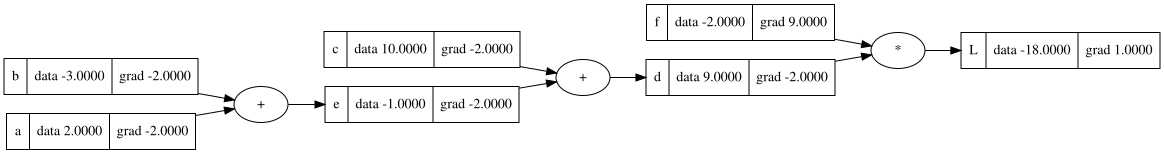

In [31]:
draw_dot(L)

In [32]:
# verify gradient

def lol():
    h = 0.001
    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a + b; e.label = "e"
    d = e + c; d.label = "d"
    f = Value(-2.0, label="f")
    L = d * f; L.label="L"
    L1 = L.data

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a + b; e.label = "e"
    d = e + c; d.label = "d"
    f = Value(-2.0 + h, label="f")
    L = d * f; L.label="L"
    L2 = L.data

    return (L2 - L1) /h
lol()

9.000000000000341

In [33]:
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

b = Value(6.8813735870195432, label="b")

x1w1 = x1 * w1; x1w1.label = "x1w1"
x2w2 = x2 * w2; x2w2.label = "x2w2"

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1*w1 + x2*w2"
n = x1w1x2w2 + b; n.label = "n"
o = n.tanh(); o.label = "o"
o.backward()

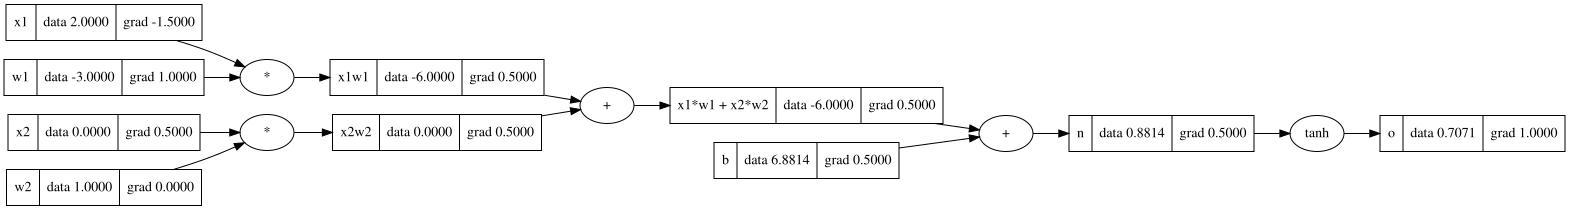

In [34]:
draw_dot(o)

In [35]:
import torch

x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print("-------------")
print("x1", x1.grad.item())
print("x2", x2.grad.item())
print("w1", w1.grad.item())
print("w2", w2.grad.item())

0.7071066904050358
-------------
x1 -1.5000003851533106
x2 0.5000001283844369
w1 1.0000002567688737
w2 0.0


In [36]:
# build MLP
class Module:

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0

    def parameters(self) -> list[Value]:
        return []

In [37]:
import random

class Neuron(Module):

    def __init__(self, nint) -> None:
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nint)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self) -> list[Value]:
        return self.w + [self.b]

class Layer(Module):

    def __init__(self, nint, nout) -> None:
        self.neurons = [Neuron(nint) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs if len(outs) > 1 else outs[0]

    def parameters(self) -> list[Value]:
        return [p for n in self.neurons for p in n.parameters()]

class MLP(Module):

    def __init__(self, nint, nout) -> None:
        size = [nint] + nout
        self.layers = [Layer(size[i], size[i + 1]) for i in range(len(nout))]
    
    def __call__(self, x):
        if isinstance(x[0], Value):
            for layer in self.layers:
                x = layer(x)
            return x
        else:
            # support batch size
            out = []
            for xx in x:
                for layer in self.layers:
                    xx = layer(xx)
                out.append(xx)
            return out

    def parameters(self) -> list[Value]:
        return [p for layer in self.layers for p in layer.parameters()]

In [47]:
mlp = MLP(3, [4, 4, 1])
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]

In [49]:
epoch = 50
lr = 0.1
for e in range(epoch):
    ypred = mlp(xs)
    loss = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred))
    print(f"Loss: {loss} at epoch: {e}")
    mlp.zero_grad()
    loss.backward()
    # update params
    for p in mlp.parameters():
        p.data -= lr * p.grad

Loss: Value(data=3.612501787294678) at epoch: 0
Loss: Value(data=3.0398656829083053) at epoch: 1
Loss: Value(data=2.080928863442042) at epoch: 2
Loss: Value(data=1.4904238288537421) at epoch: 3
Loss: Value(data=0.8695472372088241) at epoch: 4
Loss: Value(data=0.4536827022472883) at epoch: 5
Loss: Value(data=0.26749985981014923) at epoch: 6
Loss: Value(data=0.18032319427404597) at epoch: 7
Loss: Value(data=0.13286443873640638) at epoch: 8
Loss: Value(data=0.10375690038594453) at epoch: 9
Loss: Value(data=0.08434525991472419) at epoch: 10
Loss: Value(data=0.07059536505055433) at epoch: 11
Loss: Value(data=0.06040685271821458) at epoch: 12
Loss: Value(data=0.05258974374210332) at epoch: 13
Loss: Value(data=0.04642388593663362) at epoch: 14
Loss: Value(data=0.04144993718741806) at epoch: 15
Loss: Value(data=0.03736211375161959) at epoch: 16
Loss: Value(data=0.03394952100429274) at epoch: 17
Loss: Value(data=0.031062313304620365) at epoch: 18
Loss: Value(data=0.028591286323009592) at epoch:

In [50]:
ypred = mlp(xs)
print(ypred)

[Value(data=0.9718959160305279), Value(data=-0.9795263764782306), Value(data=-0.9432459797646251), Value(data=0.9455611378004845)]
